<a href="https://colab.research.google.com/github/wtryab-re/whats-your-eda-basics/blob/main/bivariate_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Bivariate analysis is a quantitative statistical method used to determine the empirical relationship between two variables (\(X\) and \(Y\)).

####Numerical-numerical (e.g., height and weight) and categorical-categorical (e.g., gender and political preference).

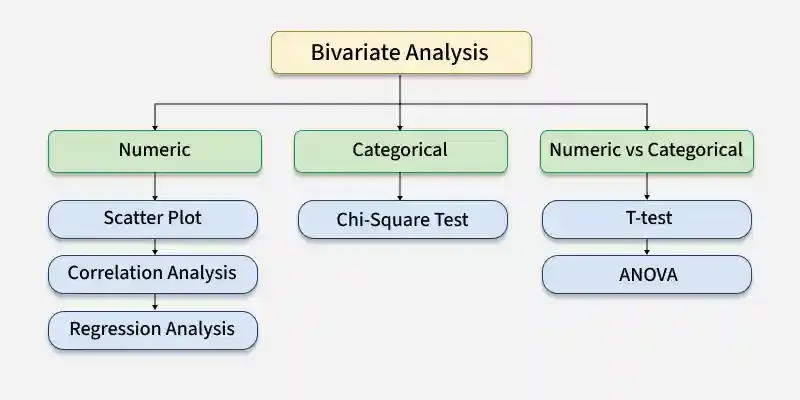

#Installation and Imports

In [2]:
!pip install -q pandas numpy seaborn matplotlib

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_style("whitegrid")

In [5]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.shape

(891, 15)

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
numeric_cols = ["age", "sibsp", "parch", "fare"]
categorical_cols = ['survived', 'pclass', 'sex','embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town','alive', 'alone']

In [9]:
df_num = df[numeric_cols].dropna()

In [10]:
df["survived_label"] = df["survived"].map({0:"No",1:"Yes"})
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True,No


# Numerical to Numerical Relationships

##Scatterplot

In [11]:
numeric_cols

['age', 'sibsp', 'parch', 'fare']

In [12]:
pairs = []
for i in range(len(numeric_cols)):
  for j in range(i+1, len(numeric_cols)):
    pairs.append((numeric_cols[i], numeric_cols[j]))

pairs

[('age', 'sibsp'),
 ('age', 'parch'),
 ('age', 'fare'),
 ('sibsp', 'parch'),
 ('sibsp', 'fare'),
 ('parch', 'fare')]

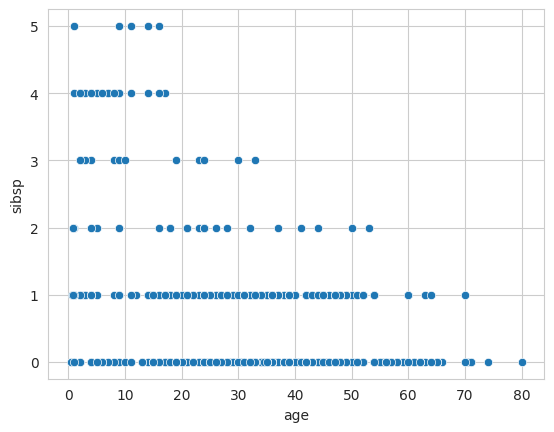

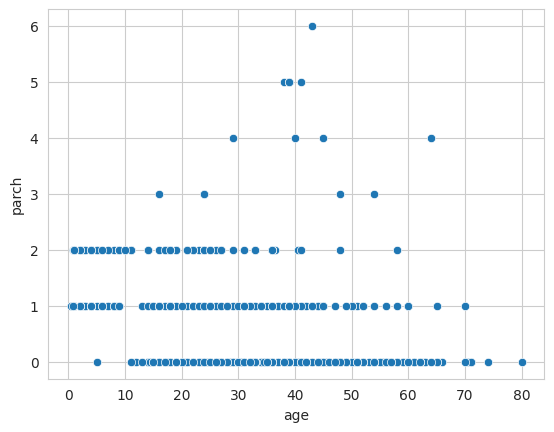

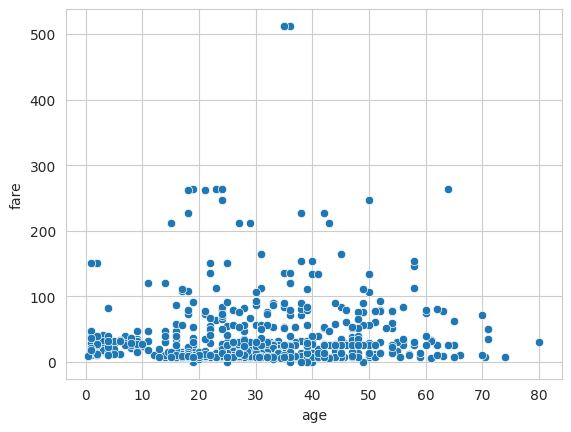

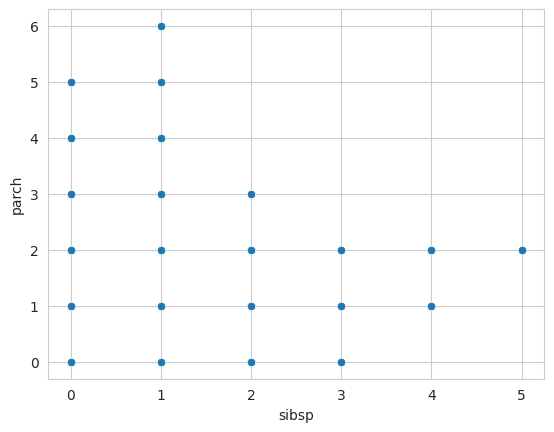

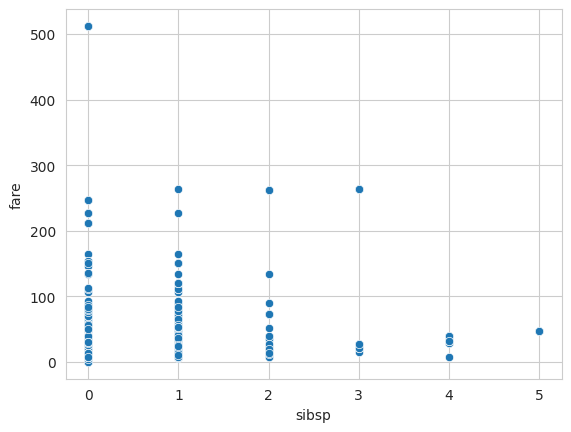

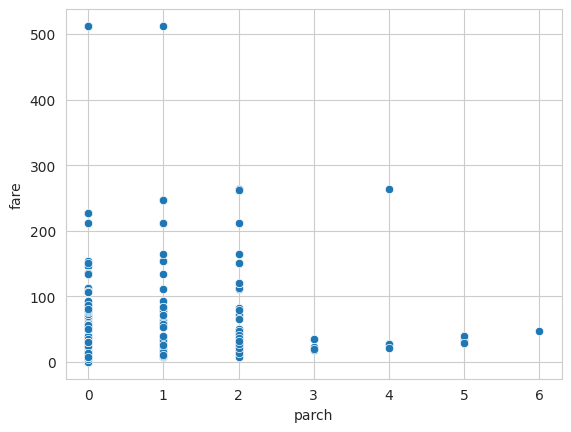

In [13]:
for x,y in pairs:
  sns.scatterplot(x=x, y=y, data=df_num)
  plt.show()

##Correlation

In [14]:
df_num.corr()

,age,sibsp,parch,fare
age,1.00,-0.31,-0.19,0.10
sibsp,-0.31,1.00,0.38,0.14
parch,-0.19,0.38,1.00,0.21
fare,0.10,0.14,0.21,1.00


<Axes: >

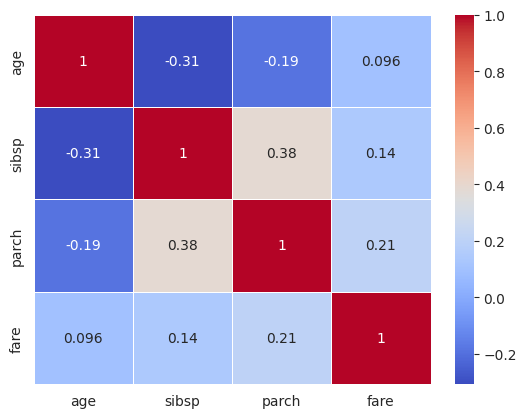

In [15]:
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

###pearson correlation coefficient
--if p is low <0.05 then it is confident that there is a relationship or else it is not.

--PCC measures correlation through a linear lens, it is possible that the correlation is not linear but some other type like quadratic.

In [16]:
!pip install -q scipy

In [17]:
from scipy.stats import pearsonr

In [18]:
for col in df_num.columns:
  for col2 in df_num.columns:
    if col !=col2:
      r,p = pearsonr(df_num[col],df_num[col2])
      print(f"Col1: {col}, Col2: {col2} R: {r:.3f}, Confidence: {p:.3f}\n{"-"*50}")

Col1: age, Col2: sibsp R: -0.308, Confidence: 0.000
--------------------------------------------------
Col1: age, Col2: parch R: -0.189, Confidence: 0.000
--------------------------------------------------
Col1: age, Col2: fare R: 0.096, Confidence: 0.010
--------------------------------------------------
Col1: sibsp, Col2: age R: -0.308, Confidence: 0.000
--------------------------------------------------
Col1: sibsp, Col2: parch R: 0.384, Confidence: 0.000
--------------------------------------------------
Col1: sibsp, Col2: fare R: 0.138, Confidence: 0.000
--------------------------------------------------
Col1: parch, Col2: age R: -0.189, Confidence: 0.000
--------------------------------------------------
Col1: parch, Col2: sibsp R: 0.384, Confidence: 0.000
--------------------------------------------------
Col1: parch, Col2: fare R: 0.205, Confidence: 0.000
--------------------------------------------------
Col1: fare, Col2: age R: 0.096, Confidence: 0.010
-----------------------

#Numerical vs Categorical

##Boxplot

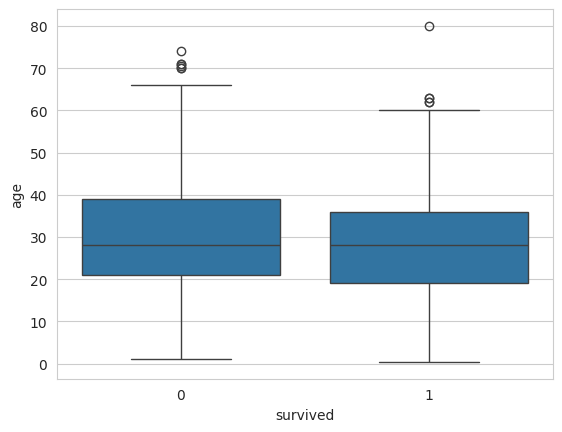

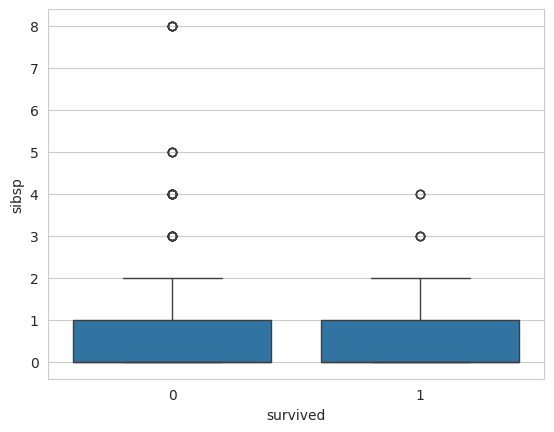

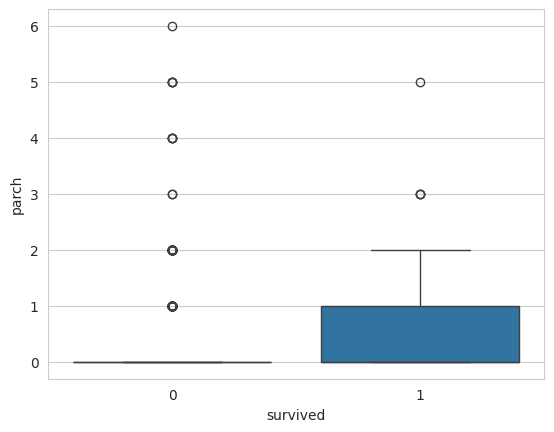

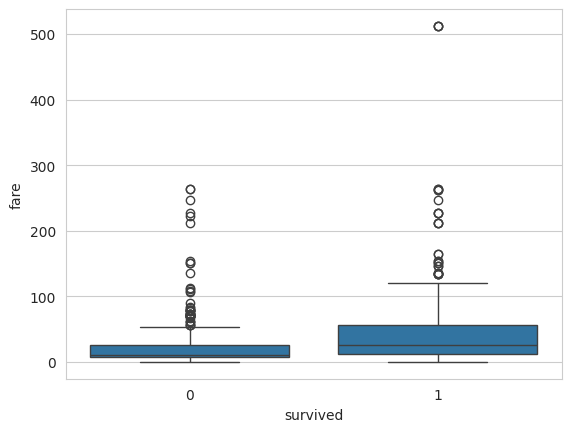

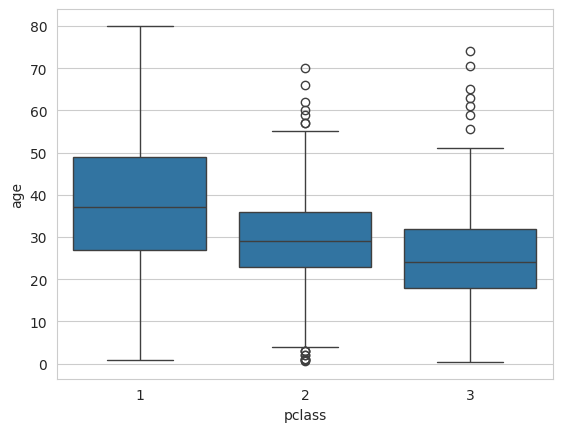

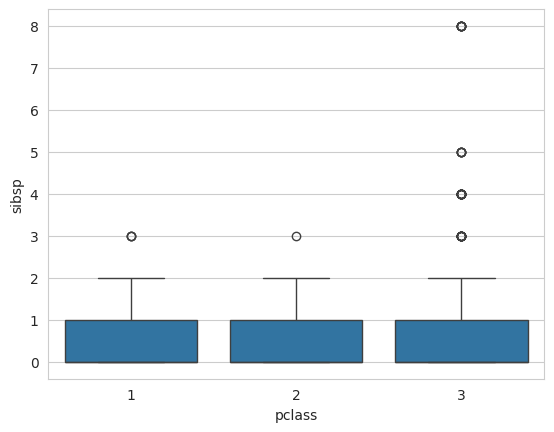

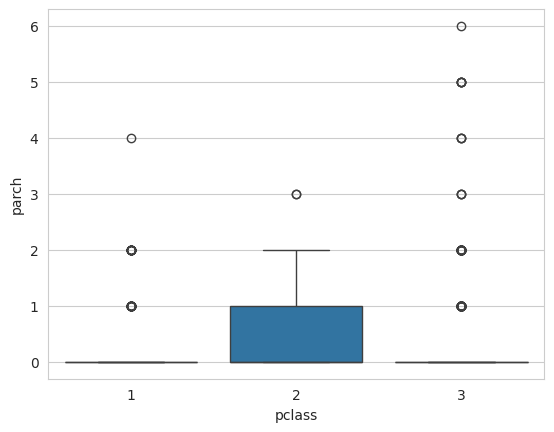

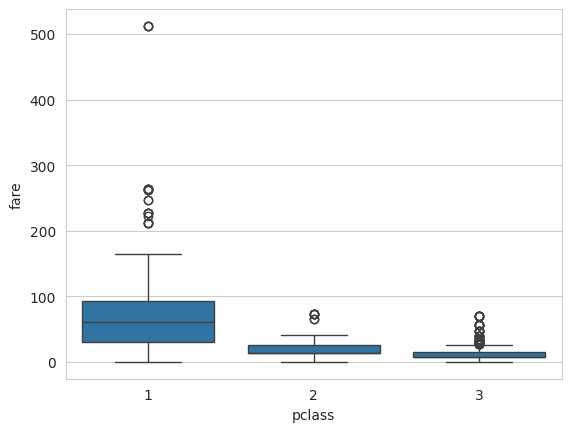

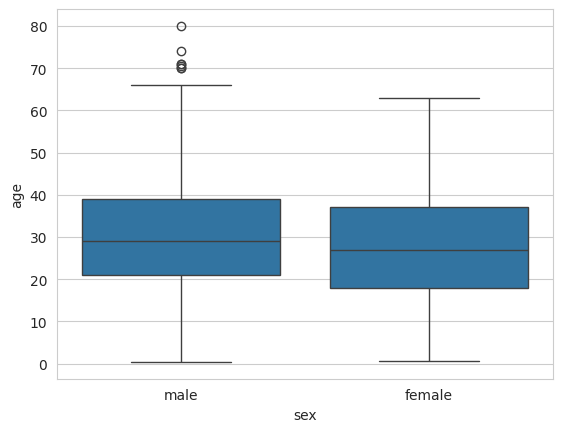

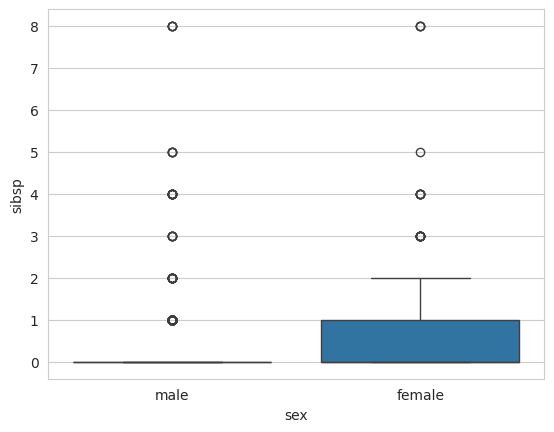

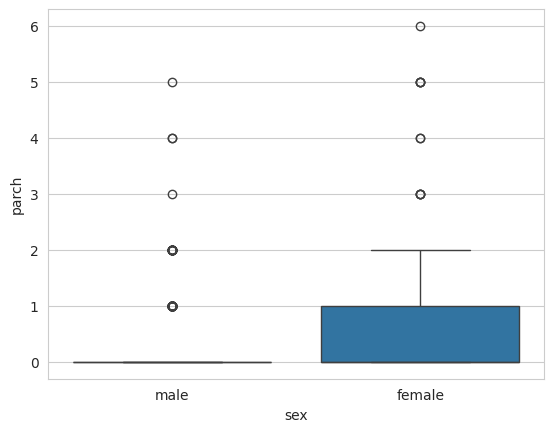

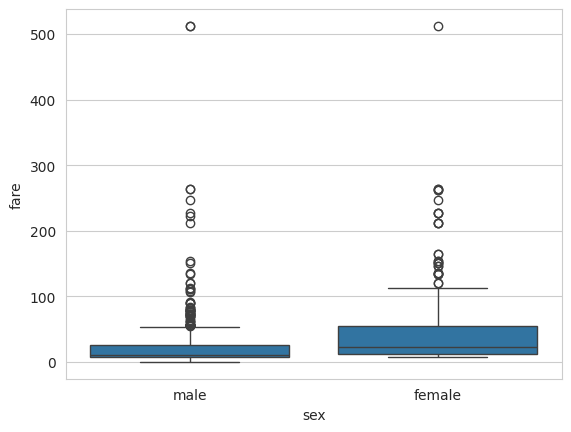

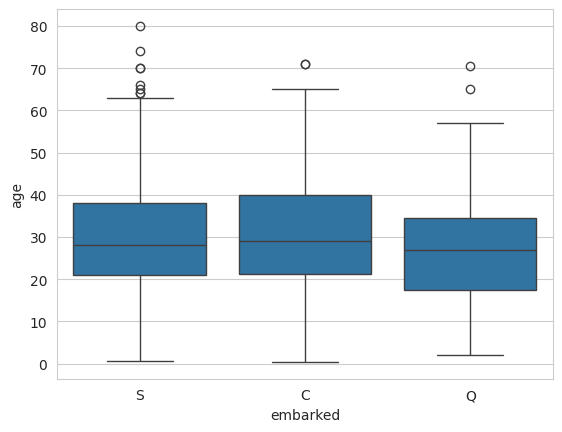

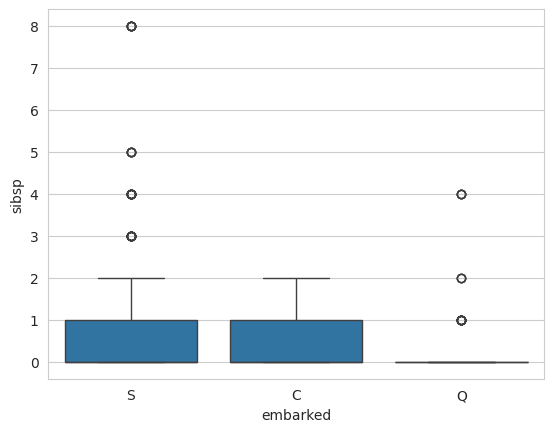

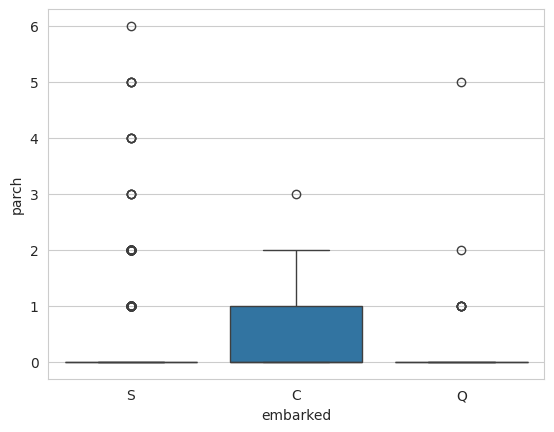

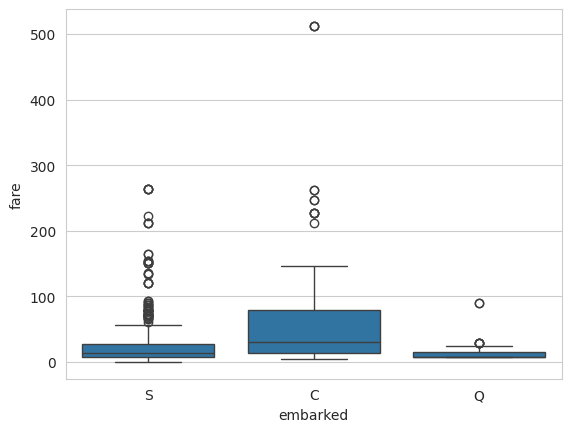

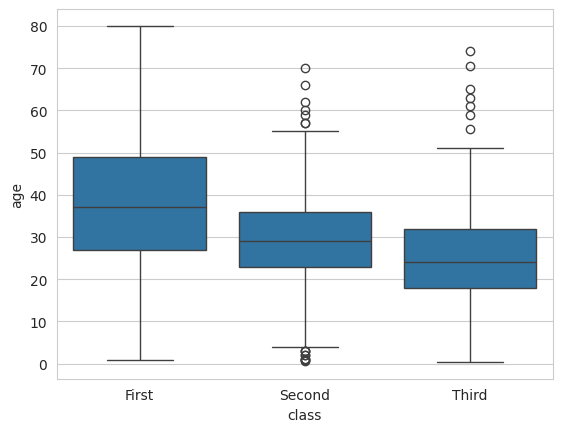

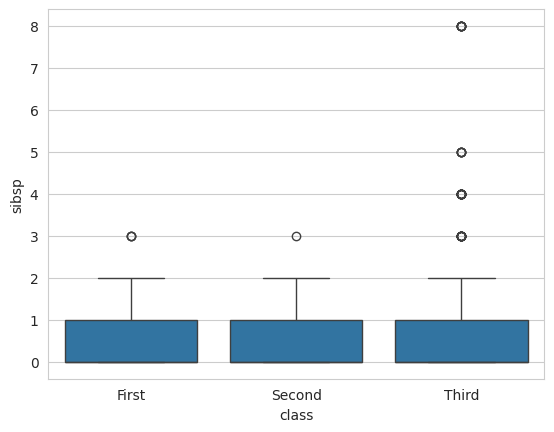

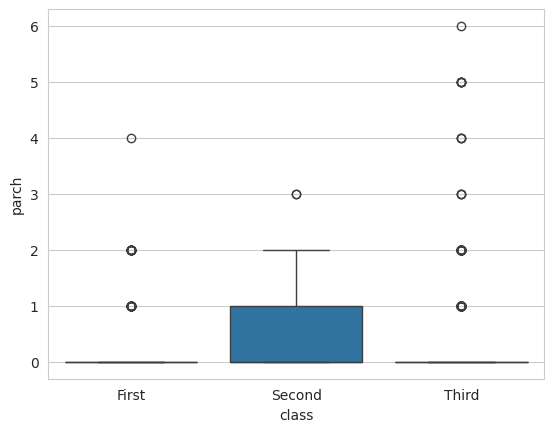

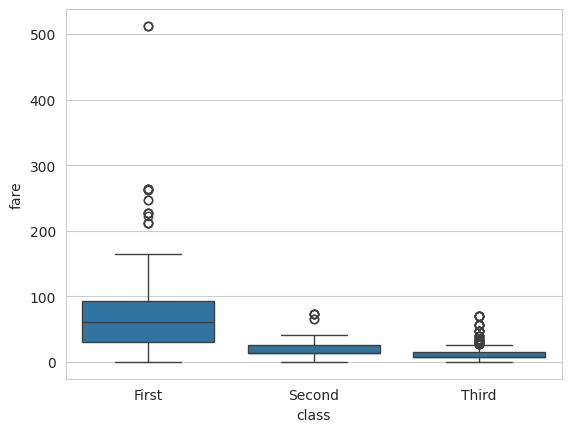

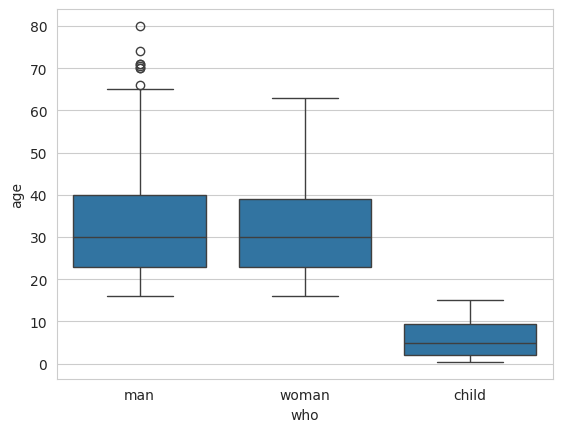

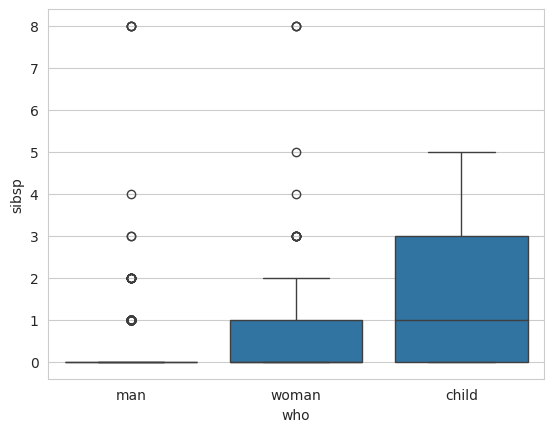

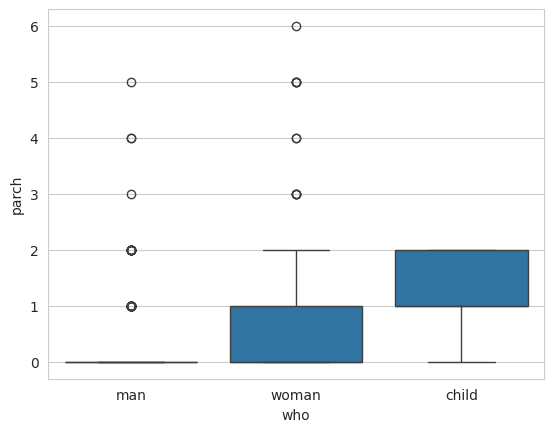

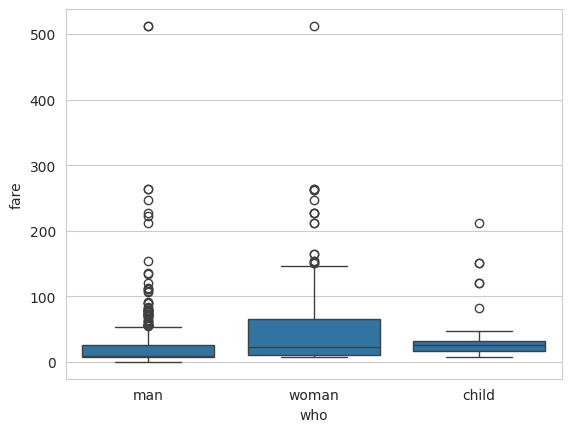

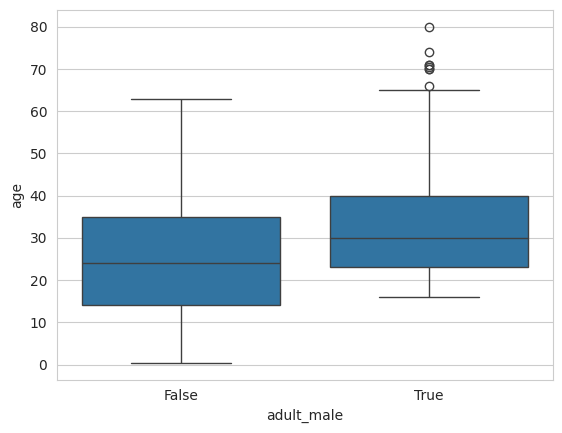

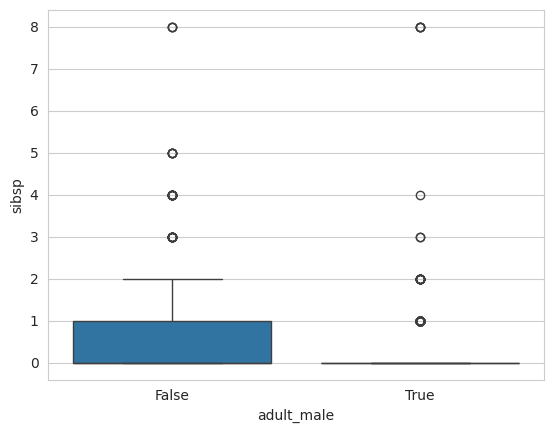

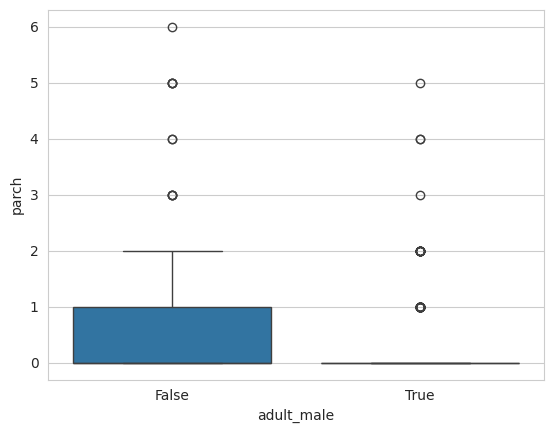

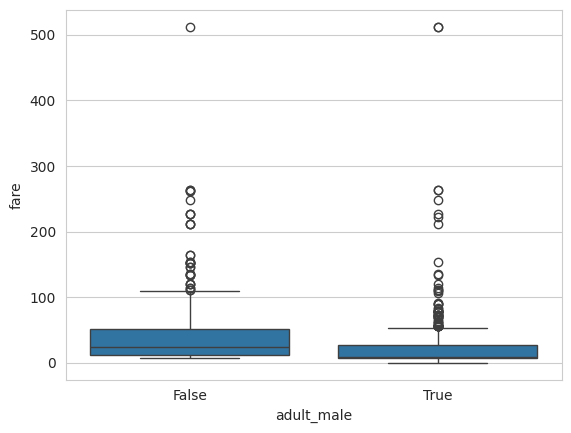

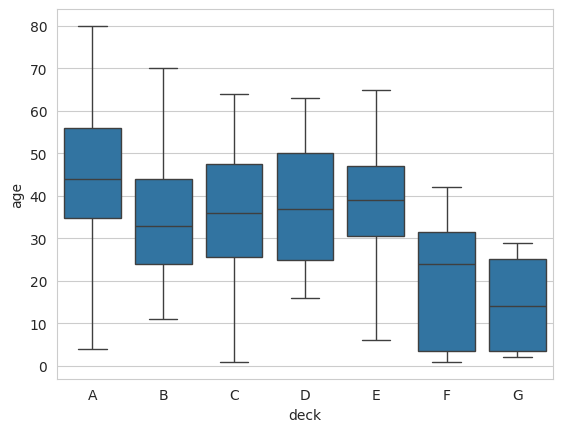

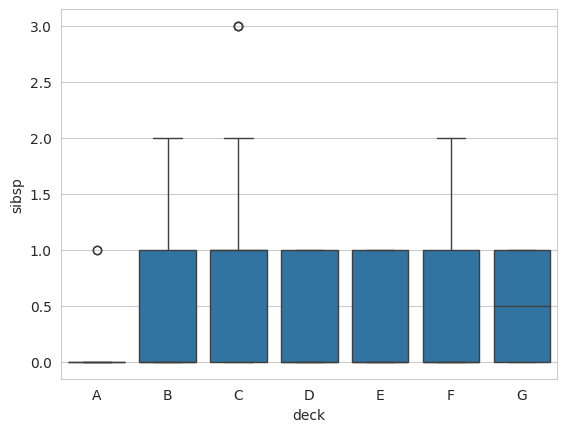

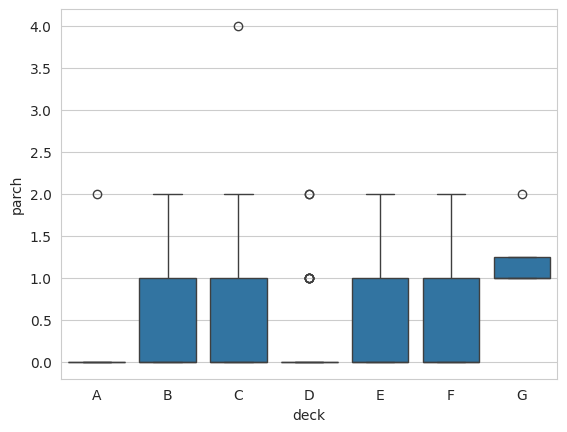

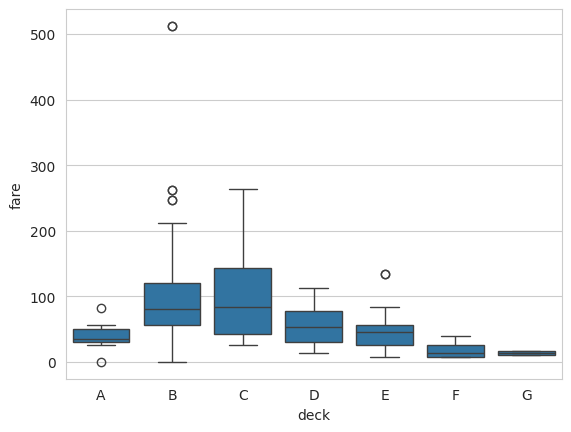

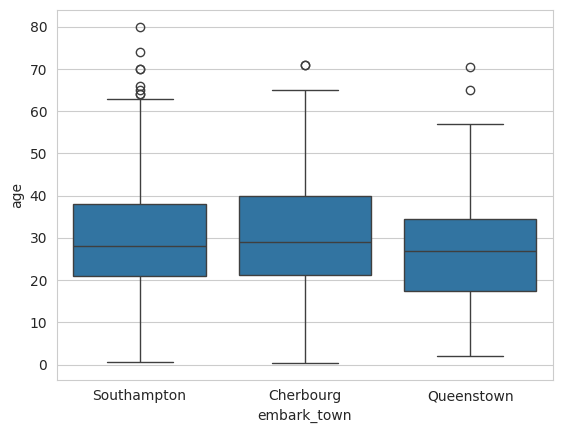

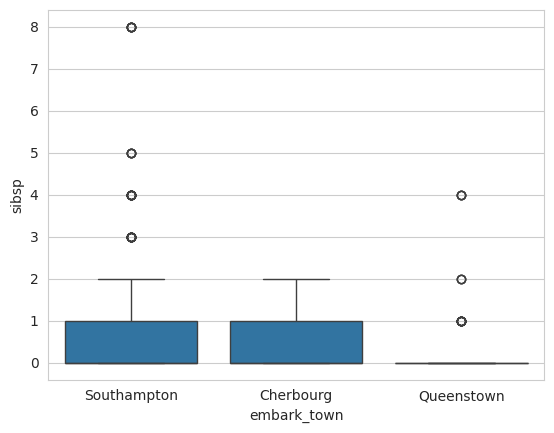

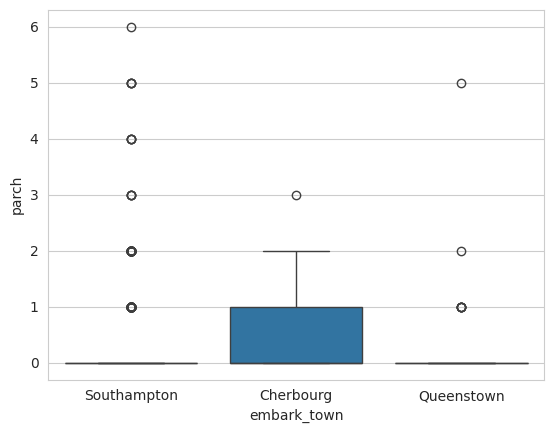

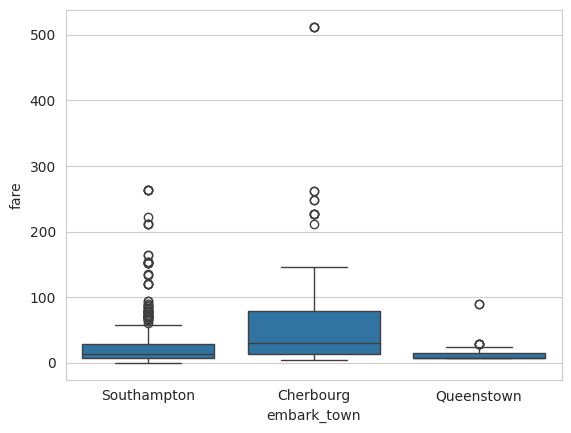

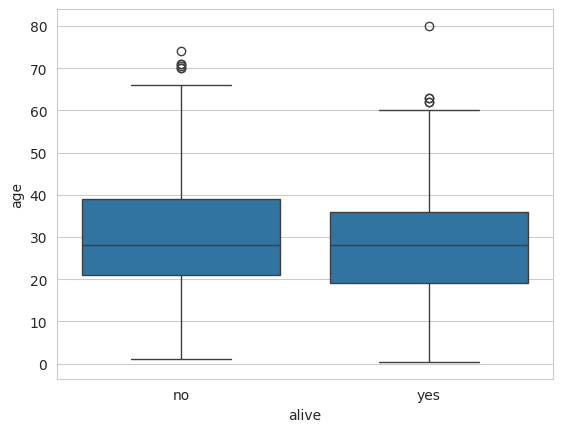

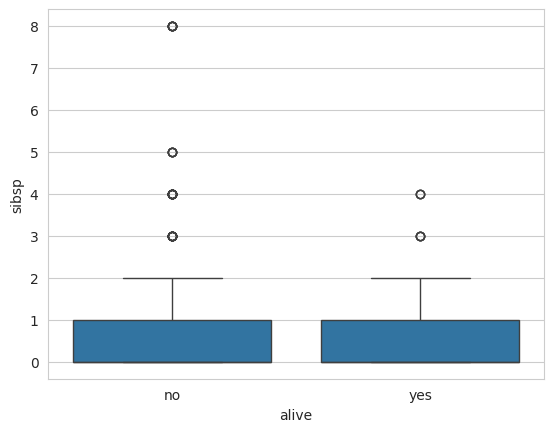

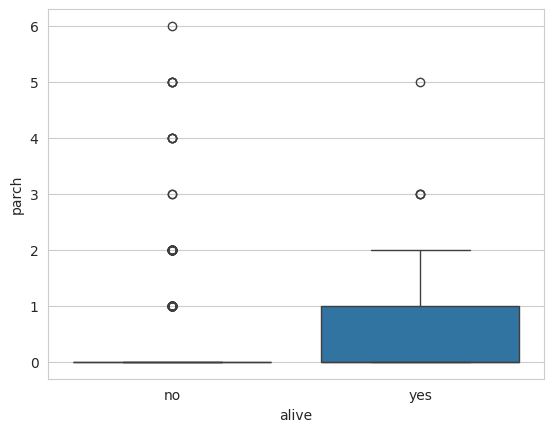

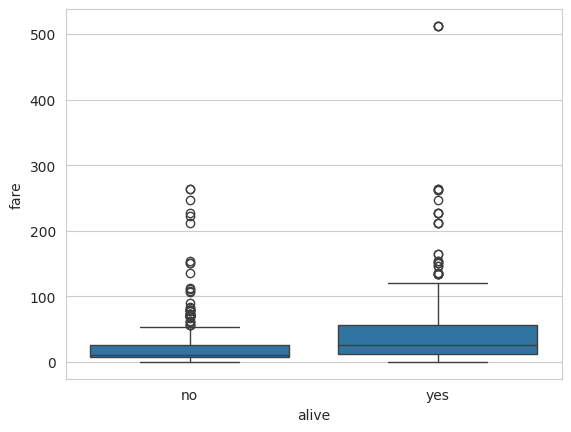

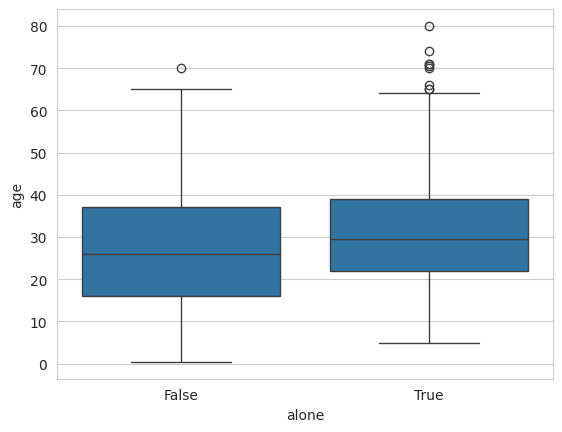

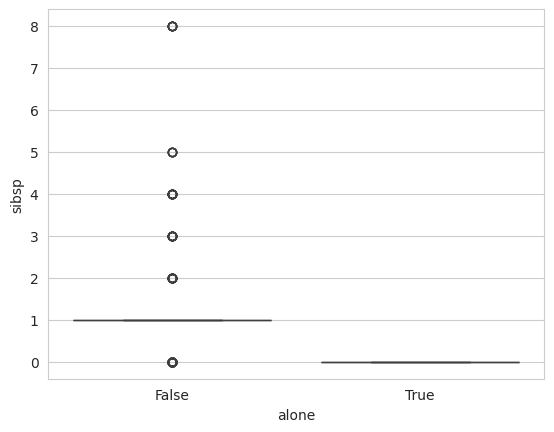

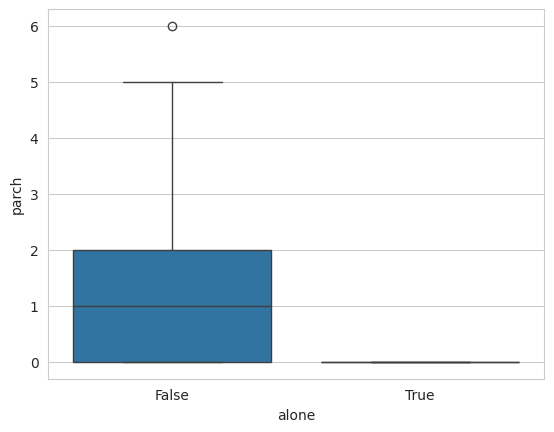

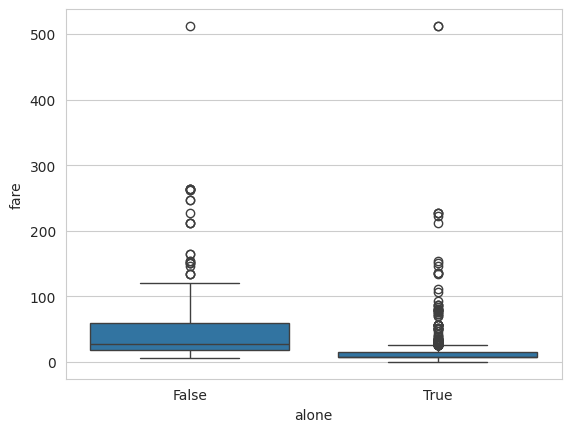

In [19]:
for col in categorical_cols:
  for col2 in numeric_cols:
    sns.boxplot(x=col, y=col2, data=df)
    plt.show()

##Grouped statistics

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.00,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,38.00,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False,Yes
2,1,3,female,26.00,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.00,1,0,53.10,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.00,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True,No


In [26]:
df[numeric_cols+["survived_label"]].groupby("survived_label").describe()

age                                           sibsp       \
                count  mean   std  min   25%   50%   75%   max  count mean   
survived_label                                                               
No             424.00 30.63 14.17 1.00 21.00 28.00 39.00 74.00 549.00 0.55   
Yes            290.00 28.34 14.95 0.42 19.00 28.00 36.00 80.00 342.00 0.47   

                                              parch                           \
                std  min  25%  50%  75%  max  count mean  std  min  25%  50%   
survived_label                                                                 
No             1.29 0.00 0.00 0.00 1.00 8.00 549.00 0.33 0.82 0.00 0.00 0.00   
Yes            0.71 0.00 0.00 0.00 1.00 4.00 342.00 0.46 0.77 0.00 0.00 0.00   

                           fare                                            
                75%  max  count  mean   std  min   25%   50%   75%    max  
survived_label                                                             
No             0.00 6.00 549.00 22.12 31.39 0.00  7.85 10.50 26.00 263.00  
Yes            1.00 5.00 342.00 48.40 66.60 0.00 12.47 26.00 57.00 512.33

#Categorical VS Categorical

##CrossTab
A crosstab (cross-tabulation or contingency table) is a statistical tool used to analyze the relationship between two or more categorical variables by displaying their frequency distributions in a table format.

In [39]:
pd.crosstab(df["survived"], df["sex"], margins=True, normalize=True)

sex,female,male,All
survived,,,
0,0.09,0.53,0.62
1,0.26,0.12,0.38
All,0.35,0.65,1.00


In [40]:
for col in categorical_cols:
  for col2 in categorical_cols:
    if col != col2:
      print(pd.crosstab(df[col], df[col2], margins=True, normalize=True))
      print("-"*50)

pclass      1    2    3  All
survived                    
0        0.09 0.11 0.42 0.62
1        0.15 0.10 0.13 0.38
All      0.24 0.21 0.55 1.00
--------------------------------------------------
sex       female  male  All
survived                   
0           0.09  0.53 0.62
1           0.26  0.12 0.38
All         0.35  0.65 1.00
--------------------------------------------------
embarked    C    Q    S  All
survived                    
0        0.08 0.05 0.48 0.62
1        0.10 0.03 0.24 0.38
All      0.19 0.09 0.72 1.00
--------------------------------------------------
class     First  Second  Third  All
survived                           
0          0.09    0.11   0.42 0.62
1          0.15    0.10   0.13 0.38
All        0.24    0.21   0.55 1.00
--------------------------------------------------
who       child  man  woman  All
survived                        
0          0.04 0.50   0.07 0.62
1          0.05 0.10   0.23 0.38
All        0.09 0.60   0.30 1.00
---------------------

##Countplots

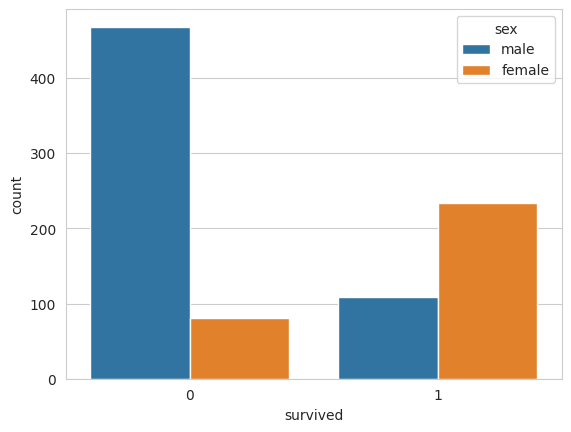

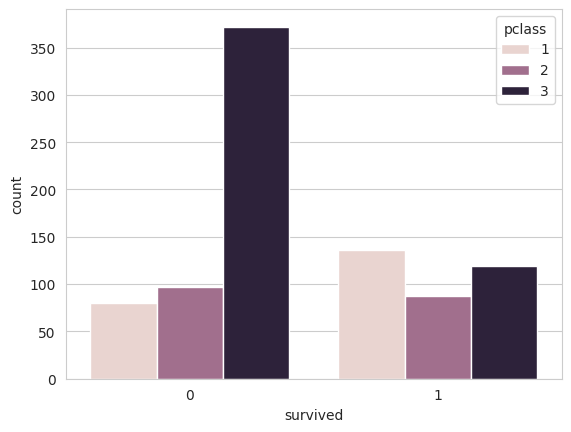

In [44]:
sns.countplot(x="survived", data=df, hue="sex")
plt.show()
sns.countplot(x="survived", data=df, hue="pclass")
plt.show()